# CatBoost YetiRank — Bayesian Hyperparameter Tuning with Optuna

**Datasets:** `featured_full_train.csv` / `featured_full_test.csv`  
**Model:** CatBoost with `YetiRank` loss function, evaluated on `MAP:top=7`  
**Tuning:** Optuna TPE Bayesian optimization — 20 trials × 3-Fold customer-level CV  
**Metric:** MAP@7  
**Explainability:** SHAP TreeExplainer

---

### Why YetiRank?

`YetiRank` is CatBoost's pairwise LTR loss — it approximates NDCG gradients by sampling pairs weighted by their rank swap impact, focusing training on getting the **top positions right** (exactly what MAP@7 rewards).  
`eval_metric = 'MAP:top=7'` is used to monitor per-fold MAP during training.

### Why Optuna?

Optuna uses **Tree-structured Parzen Estimator (TPE)** — a Bayesian method that models which hyperparameter regions yielded good results so far, and samples more from promising regions.  
This converges to good configs much faster than random or grid search.

### Pipeline
```
featured_full_train.csv
  → Drop leaky columns (_grp_pct, _grp_zscore, _is_train if present)
  → Sort by customer (id2) for contiguous LTR groups
  → CAT_FEATURES = [] (all columns already int-encoded by feature_engineering.ipynb)
  → Optuna: 20 trials × 3-Fold customer-level CV (maximize mean MAP@7)
  → Retrain best Optuna params on full 3-Fold CV → OOF predictions
  → Final evaluation on test set (MAP@7, AUC)
  → SHAP analysis on best fold model
```

## 1. Imports

Imports: `numpy`, `pandas`, `matplotlib`, `catboost` (CatBoost, Pool), `optuna`, `shap`, `sklearn.metrics`.  
CatBoost and Optuna logging are silenced so only trial results and training progress are visible.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore',category=UserWarning)
import logging
import os

# Suppress CatBoost and other library output
logging.getLogger('catboost').setLevel(logging.CRITICAL)
os.environ['CATBOOST_LOGGING_LEVEL'] = 'Silent'

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from catboost import CatBoost, Pool
from sklearn.metrics import roc_auc_score
import shap

print(f'Optuna  version : {optuna.__version__}')
print(f'SHAP    version : {shap.__version__}')
print('Libraries imported successfully')

Optuna  version : 4.8.0
SHAP    version : 0.50.0
Libraries imported successfully


## 2. Load Data

Reads `featured_full_train.csv` and `featured_full_test.csv` from Kaggle input paths.  
Drops leaky columns if present: any column ending in `_grp_pct`, `_grp_zscore`, or named `_is_train`.

In [22]:
TRAIN_PATH = '/kaggle/input/datasets/akashjaiswal1101/amex-dataset/featured_full_train (1).csv'
TEST_PATH  = '/kaggle/input/datasets/akashjaiswal1101/amex-dataset/featured_full_test (1).csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

# Drop any leaky columns that should never reach the model
leaky_cols = [c for c in train.columns
              if c.endswith('_grp_pct') or c.endswith('_grp_zscore') or c == '_is_train']
if leaky_cols:
    train.drop(columns=leaky_cols, inplace=True)
    test.drop(columns=[c for c in leaky_cols if c in test.columns], inplace=True)
    print(f'Dropped {len(leaky_cols)} leaky columns: {leaky_cols}')

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')

Train shape : (616602, 350)
Test  shape : (153544, 350)


In [23]:
print('Target distribution (train):')
print(train['y'].value_counts(normalize=True).round(4))
print(f'\nUnique customers (train): {train["id2"].nunique()}')
print(f'Unique customers (test) : {test["id2"].nunique()}')
print(f'Avg offers/customer (train): {train.groupby("id2").size().mean():.1f}')

Target distribution (train):
y
0    0.9512
1    0.0488
Name: proportion, dtype: float64

Unique customers (train): 37240
Unique customers (test) : 9310
Avg offers/customer (train): 16.6


## 3. Feature & Column Definitions

- **ID columns:** `id1`–`id5` — excluded from training  
- **Target:** `y` (binary: 1 = offer clicked)  
- **Group column:** `id2` (customer ID — used for LTR group splits)  
- **`CAT_FEATURES = []`** — all categorical columns were already integer-encoded by `feature_engineering.ipynb` using `pd.CategoricalDtype` fitted on train rows only (no leakage). Declaring them as CatBoost `cat_features` would cause redundant internal target-statistics re-encoding. Treated as plain numeric features.  
- **`FEATURE_COLS`** — all columns except IDs and target.

In [24]:
ID_COLS    = ['id1', 'id2', 'id3', 'id4', 'id5']
TARGET_COL = 'y'
GROUP_COL  = 'id2'

# All categorical columns were already integer-encoded by feature_engineering.ipynb
# using pd.CategoricalDtype fitted on train rows only — no leakage.
# Declaring them as CatBoost cat_features causes redundant (and potentially leaky)
# internal target-statistics re-encoding. Treat as plain numeric features.
CAT_FEATURES = []

FEATURE_COLS = [c for c in train.columns if c not in ID_COLS + [TARGET_COL]]

print(f'Total features      : {len(FEATURE_COLS)}')
print(f'Categorical features: 0 (already int-encoded by feature_engineering.ipynb)')

Total features      : 344
Categorical features: 0 (already int-encoded by feature_engineering.ipynb)


## 4. Preprocessing

All features are already numeric (integer-encoded by `feature_engineering.ipynb`) — **no string conversion or NaN-filling is needed**.

Steps:
1. Sort by `id2` (customer ID) — **mandatory** for CatBoost LTR: groups must be contiguous
2. Assign `X_train`, `y_train`, `X_test`, `y_test`, `train_groups`, `test_groups`

In [25]:
# No string conversion needed — all features are numeric after feature_engineering.ipynb.
# Sort by id2 (mandatory for CatBoost LTR: contiguous groups per customer).
train = train.sort_values(GROUP_COL).reset_index(drop=True)
test  = test.sort_values(GROUP_COL).reset_index(drop=True)

X_train      = train[FEATURE_COLS]
y_train      = train[TARGET_COL]
X_test       = test[FEATURE_COLS]
y_test       = test[TARGET_COL]
train_groups = train[GROUP_COL].values
test_groups  = test[GROUP_COL].values

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_train positive rate: {y_train.mean():.4f}')
print(f'y_test  positive rate: {y_test.mean():.4f}')
print('Sorted by customer — groups are contiguous ✓')

X_train : (616602, 344)
X_test  : (153544, 344)
y_train positive rate: 0.0488
y_test  positive rate: 0.0455
Sorted by customer — groups are contiguous ✓


## 5. MAP@K Evaluation Metric

MAP@7 is computed **per customer (query group)**:
1. Rank offers by predicted score (descending)
2. For each clicked offer appearing in the top-K, compute precision at that rank
3. Average precision values → AP for that customer
4. Average AP across all customers → MAP@7

Two helpers defined: `apk(actual, predicted, k)` and `map_at_k(y_true, y_score, k, groups)`.

In [26]:
def apk(actual: list, predicted: list, k: int = 7) -> float:
    """Average Precision at K for a single query."""
    if not actual:
        return 0.0
    predicted = predicted[:k]
    score, num_hits = 0.0, 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k)


def map_at_k(y_true, y_score, k=7, groups=None):
    """MAP@K computed per customer group."""
    if groups is None:
        order  = np.argsort(y_score)[::-1]
        actual = list(np.where(y_true == 1)[0])
        return apk(actual, list(order), k)

    ap_scores = []
    for grp in np.unique(groups):
        mask = groups == grp
        yt   = np.array(y_true)[mask]
        ys   = np.array(y_score)[mask]
        if yt.sum() == 0:
            continue
        order     = np.argsort(ys)[::-1]
        actual    = list(np.where(yt == 1)[0])
        predicted = list(order)
        ap_scores.append(apk(actual, predicted, k))

    return float(np.mean(ap_scores)) if ap_scores else 0.0

print('MAP@K helpers defined.')

MAP@K helpers defined.


## 6. Customer-Level 3-Fold CV Splits

Customers are shuffled with `np.random.default_rng(42)` and split into 3 equal groups via `np.array_split`.  
These fixed `customer_folds` are created **once** and reused identically in:
- The Optuna objective function (hyperparameter tuning)
- The final retrain loop (OOF collection and evaluation)

This guarantees the same fold assignment across both phases.

In [27]:
N_FOLDS      = 3
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

unique_customers = train[GROUP_COL].unique()
rng.shuffle(unique_customers)
customer_folds = np.array_split(unique_customers, N_FOLDS)

print(f'Total unique customers: {len(unique_customers)}')
for i, fold_custs in enumerate(customer_folds):
    fold_rows = train[train[GROUP_COL].isin(fold_custs)].shape[0]
    print(f'  Fold {i+1}: {len(fold_custs):5d} customers | {fold_rows:6d} rows')

Total unique customers: 37240
  Fold 1: 12414 customers | 205773 rows
  Fold 2: 12413 customers | 204584 rows
  Fold 3: 12413 customers | 206245 rows


## 7. Bayesian Hyperparameter Tuning — Optuna (20 Trials)

### Search Space

| Parameter | Range / Choices | Type |
|---|---|---|
| `iterations` | 200 – 1000 | int |
| `learning_rate` | 0.01 – 0.3 | float, log-uniform |
| `depth` | 4 – 10 | int |
| `l2_leaf_reg` | 1.0 – 10.0 | float |
| `bagging_temperature` | 0.0 – 1.0 | float |
| `random_strength` | 1e-9 – 10.0 | float, log-uniform |
| `border_count` | 32, 64, 128, 254 | categorical |

### Fixed Params (not tuned)

| Parameter | Value |
|---|---|
| `loss_function` | `YetiRank` |
| `eval_metric` | `MAP:top=7` |
| `early_stopping_rounds` | 50 |
| `task_type` | `GPU` (device `0`) |
| `grow_policy` | `Depthwise` |

**Objective:** mean MAP@7 across the 3 fixed customer-level CV folds (maximized).  
**Sampler:** Optuna TPE (`TPESampler(seed=42)`).  
`Pool` objects are constructed **without** `cat_features` — all features are already integer-encoded.

In [28]:
N_TRIALS = 20

def objective(trial):
    params = dict(
        iterations          = trial.suggest_int('iterations', 200, 1000),
        learning_rate       = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        depth               = trial.suggest_int('depth', 4, 10),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        random_strength     = trial.suggest_float('random_strength', 1e-9, 10.0, log=True),
        border_count        = trial.suggest_categorical('border_count', [32, 64, 128, 254]),
        # Fixed
        loss_function         = 'YetiRank',
        eval_metric           = 'MAP:top=7',
        random_seed           = RANDOM_STATE,
        early_stopping_rounds = 50,
        verbose               = False,
        task_type             = 'GPU',
        devices               = '0',
        grow_policy           = 'Depthwise',
    )

    fold_maps = []
    for val_customers in customer_folds:
        val_mask   = train[GROUP_COL].isin(val_customers)
        train_mask = ~val_mask

        X_tr  = X_train[train_mask];  y_tr  = y_train[train_mask];  g_tr  = train_groups[train_mask]
        X_val = X_train[val_mask];    y_val = y_train[val_mask];    g_val = train_groups[val_mask]

        # No cat_features — all columns already int-encoded by feature_engineering.ipynb
        train_pool = Pool(data=X_tr,  label=y_tr,  group_id=g_tr)
        val_pool   = Pool(data=X_val, label=y_val, group_id=g_val)

        model = CatBoost(params)
        model.fit(train_pool, eval_set=val_pool)

        val_scores = model.predict(val_pool)
        fold_maps.append(map_at_k(y_val.values, val_scores, k=7, groups=g_val))

    return float(np.mean(fold_maps))


print(f'Starting Optuna study: {N_TRIALS} trials × {N_FOLDS}-Fold CV')
print('Objective: maximize mean MAP@7 across folds')
print('─' * 60)

study = optuna.create_study(
    direction  = 'maximize',
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name = 'catboost_lambdamart_map7'
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('\n' + '─' * 60)
print(f'Best trial  : #{study.best_trial.number}')
print(f'Best MAP@7  : {study.best_value:.4f}')
print('Best params :')
for k, v in study.best_params.items():
    print(f'  {k:30s}: {v}')

Starting Optuna study: 20 trials × 3-Fold CV
Objective: maximize mean MAP@7 across folds
────────────────────────────────────────────────────────────


  0%|          | 0/20 [00:00<?, ?it/s]

Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metri


────────────────────────────────────────────────────────────
Best trial  : #17
Best MAP@7  : 0.6824
Best params :
  iterations                    : 878
  learning_rate                 : 0.15089640576494415
  depth                         : 5
  l2_leaf_reg                   : 4.890188049514378
  bagging_temperature           : 0.4114671391322019
  random_strength               : 1.2132477128115758e-07
  border_count                  : 254


## 8. Optuna Visualisations

Two plots side by side:
1. **Trial MAP@7 History** — scatter of each trial's MAP@7 with a running best-so-far line overlay
2. **Hyperparameter Importance** — horizontal bar chart using `optuna.importance.get_param_importances`

Also displays all 20 trial results as a sorted DataFrame (`study.trials_dataframe()`).

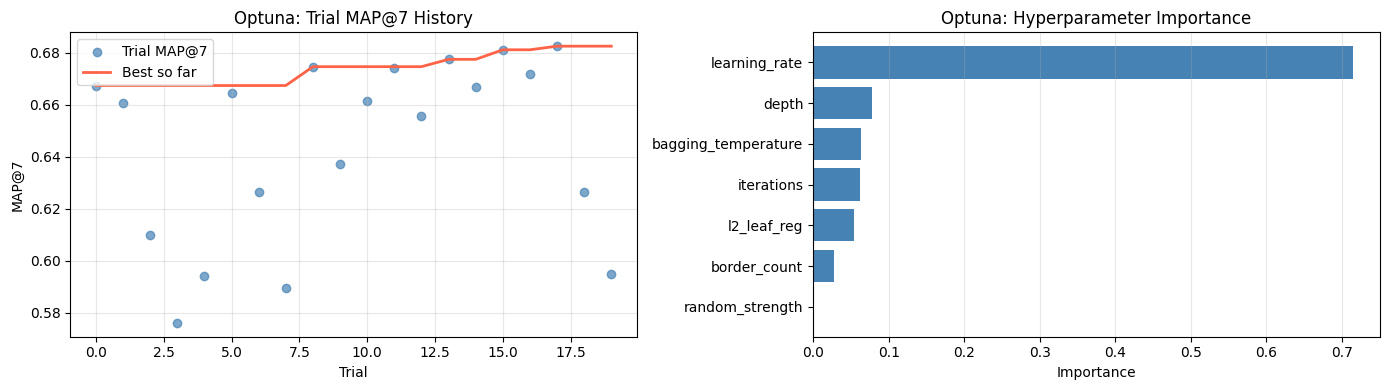

In [29]:
# Trial history — MAP@7 vs trial number
trial_nums  = [t.number for t in study.trials]
trial_maps  = [t.value  for t in study.trials]
best_so_far = np.maximum.accumulate(trial_maps)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(trial_nums, trial_maps, alpha=0.7, color='steelblue', label='Trial MAP@7')
axes[0].plot(trial_nums, best_so_far, color='tomato', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('MAP@7')
axes[0].set_title('Optuna: Trial MAP@7 History')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Param importance (manual — mean |value - mean| weighted by rank)
importances = optuna.importance.get_param_importances(study)
param_names = list(importances.keys())
param_vals  = list(importances.values())

axes[1].barh(param_names[::-1], param_vals[::-1], color='steelblue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Optuna: Hyperparameter Importance')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [30]:
# All trial results as a DataFrame
trials_df = study.trials_dataframe().sort_values('value', ascending=False)
print('All 20 trials (sorted by MAP@7):')
display(trials_df[['number', 'value'] + [c for c in trials_df.columns if c.startswith('params_')]]
        .rename(columns={'value': 'MAP@7', 'number': 'Trial'})
        .reset_index(drop=True)
        .round(5)
        .head(20))

All 20 trials (sorted by MAP@7):


,Trial,MAP@7,params_bagging_temperature,params_border_count,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength
0,17,0.68244,0.41147,254,5,878,4.89019,0.15090,0.00000
1,15,0.68106,0.37290,128,5,860,2.35066,0.16522,0.00000
2,13,0.67738,0.41286,64,6,833,1.64805,0.15845,0.00000
3,8,0.67456,0.31098,128,6,891,1.57203,0.08331,0.00000
4,11,0.67421,0.00804,64,7,468,6.86166,0.27740,0.00000
5,16,0.67179,0.57957,32,5,745,2.63147,0.18812,0.00006
6,0,0.66732,0.15602,64,9,500,6.38793,0.25370,0.00000
7,14,0.66683,0.40547,64,6,813,1.04083,0.07931,0.00000
8,5,0.66448,0.59790,254,10,976,9.05345,0.13963,1.65479
9,10,0.66135,0.02445,128,6,984,1.16166,0.04729,0.00000


## 9. Retrain with Best Optuna Params — Full 3-Fold CV

`BEST_PARAMS` is assembled from `study.best_params` plus fixed params:
- `loss_function = 'YetiRank'`
- `eval_metric = 'MAP:top=7'`
- `task_type = 'GPU'`, `devices = '0'`
- `early_stopping_rounds = 50`, `verbose = 100`

Retrains on all 3 folds using the same `customer_folds` as Optuna.  
Collects OOF predictions (unbiased train evaluation) and averages test predictions across folds.  
`Pool` objects built **without** `cat_features`.

In [31]:
BEST_PARAMS = dict(
    **study.best_params,
    loss_function         = 'YetiRank',
    eval_metric           = 'MAP:top=7',
    random_seed           = RANDOM_STATE,
    early_stopping_rounds = 50,
    verbose               = 100,
    task_type             = 'GPU',
    devices               = '0',
)

print('Final training params:')
for k, v in BEST_PARAMS.items():
    print(f'  {k:30s}: {v}')

Final training params:
  iterations                    : 878
  learning_rate                 : 0.15089640576494415
  depth                         : 5
  l2_leaf_reg                   : 4.890188049514378
  bagging_temperature           : 0.4114671391322019
  random_strength               : 1.2132477128115758e-07
  border_count                  : 254
  loss_function                 : YetiRank
  eval_metric                   : MAP:top=7
  random_seed                   : 42
  early_stopping_rounds         : 50
  verbose                       : 100
  task_type                     : GPU
  devices                       : 0


In [32]:
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
fold_maps  = []
fold_aucs  = []
models     = []

for fold_idx, val_customers in enumerate(customer_folds, 1):
    print(f'\n{"="*60}')
    print(f'FOLD {fold_idx}/{N_FOLDS}')
    print(f'{"="*60}')

    val_mask   = train[GROUP_COL].isin(val_customers)
    train_mask = ~val_mask

    X_tr, y_tr, g_tr     = X_train[train_mask], y_train[train_mask], train_groups[train_mask]
    X_val, y_val, g_val  = X_train[val_mask],   y_train[val_mask],   train_groups[val_mask]

    print(f'Train: {len(X_tr):6d} rows | {len(np.unique(g_tr)):5d} customers')
    print(f'Val  : {len(X_val):6d} rows | {len(np.unique(g_val)):5d} customers')

    # No cat_features — all columns already int-encoded by feature_engineering.ipynb
    train_pool = Pool(data=X_tr,  label=y_tr,  group_id=g_tr)
    val_pool   = Pool(data=X_val, label=y_val, group_id=g_val)

    model = CatBoost(BEST_PARAMS)
    model.fit(train_pool, eval_set=val_pool)

    val_scores = model.predict(val_pool)
    oof_preds[val_mask.values] = val_scores

    test_pool = Pool(data=X_test, group_id=test_groups)
    test_preds += model.predict(test_pool) / N_FOLDS

    fold_map = map_at_k(y_val.values, val_scores, k=7, groups=g_val)
    fold_auc = roc_auc_score(y_val.values, val_scores)
    fold_maps.append(fold_map)
    fold_aucs.append(fold_auc)
    models.append(model)

    print(f'\nFold {fold_idx} -> AUC: {fold_auc:.4f} | MAP@7: {fold_map:.4f}')

print(f'\n{"="*60}')
print(f'CV AUC  : {np.mean(fold_aucs):.4f} +/- {np.std(fold_aucs):.4f}')
print(f'CV MAP@7: {np.mean(fold_maps):.4f} +/- {np.std(fold_maps):.4f}')
print(f'{"="*60}')


FOLD 1/3
Train: 410829 rows | 24826 customers
Val  : 205773 rows | 12414 customers


Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0365910	test: 0.0365177	best: 0.0365177 (0)	total: 98.2ms	remaining: 1m 26s
100:	learn: 0.0631652	test: 0.0622346	best: 0.0622346 (100)	total: 3.18s	remaining: 24.5s
200:	learn: 0.0672204	test: 0.0658737	best: 0.0658737 (200)	total: 6.13s	remaining: 20.6s
300:	learn: 0.0693089	test: 0.0675625	best: 0.0675969 (298)	total: 9.02s	remaining: 17.3s
400:	learn: 0.0707983	test: 0.0689486	best: 0.0689745 (399)	total: 11.9s	remaining: 14.2s
500:	learn: 0.0720599	test: 0.0701063	best: 0.0701804 (498)	total: 14.8s	remaining: 11.2s
600:	learn: 0.0728797	test: 0.0707666	best: 0.0708583 (593)	total: 17.7s	remaining: 8.17s
700:	learn: 0.0736907	test: 0.0712384	best: 0.0712384 (700)	total: 20.7s	remaining: 5.22s
800:	learn: 0.0742618	test: 0.0718000	best: 0.0718015 (798)	total: 23.6s	remaining: 2.27s
877:	learn: 0.0747386	test: 0.0718875	best: 0.0719416 (854)	total: 25.8s	remaining: 0us
bestTest = 0.07194160724
bestIteration = 854
Shrink model to first 855 iterations.

Fold 1 -> AUC: 0.937

Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0287102	test: 0.0296779	best: 0.0296779 (0)	total: 76.8ms	remaining: 1m 7s
100:	learn: 0.0630460	test: 0.0632305	best: 0.0632305 (100)	total: 3.12s	remaining: 24s
200:	learn: 0.0666250	test: 0.0669465	best: 0.0669465 (200)	total: 6s	remaining: 20.2s
300:	learn: 0.0685520	test: 0.0686011	best: 0.0686011 (300)	total: 8.81s	remaining: 16.9s
400:	learn: 0.0700236	test: 0.0699926	best: 0.0699926 (400)	total: 11.6s	remaining: 13.9s
500:	learn: 0.0712254	test: 0.0709571	best: 0.0709722 (496)	total: 14.5s	remaining: 10.9s
600:	learn: 0.0721839	test: 0.0718870	best: 0.0718870 (600)	total: 17.4s	remaining: 8s
700:	learn: 0.0728737	test: 0.0724283	best: 0.0724316 (695)	total: 20.2s	remaining: 5.1s
800:	learn: 0.0735302	test: 0.0727114	best: 0.0727643 (799)	total: 23s	remaining: 2.21s
877:	learn: 0.0738879	test: 0.0728235	best: 0.0728499 (851)	total: 25.2s	remaining: 0us
bestTest = 0.07284985403
bestIteration = 851
Shrink model to first 852 iterations.

Fold 2 -> AUC: 0.9365 | MAP@7: 0

Default metric period is 5 because PFound, MAP is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric MAP:top=7 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.0310861	test: 0.0292256	best: 0.0292256 (0)	total: 76.9ms	remaining: 1m 7s
100:	learn: 0.0635717	test: 0.0616050	best: 0.0616976 (98)	total: 3.04s	remaining: 23.4s
200:	learn: 0.0672167	test: 0.0652194	best: 0.0652194 (200)	total: 5.86s	remaining: 19.7s
300:	learn: 0.0695288	test: 0.0669621	best: 0.0670103 (296)	total: 8.68s	remaining: 16.6s
400:	learn: 0.0713104	test: 0.0680715	best: 0.0680715 (400)	total: 11.5s	remaining: 13.7s
500:	learn: 0.0724350	test: 0.0689547	best: 0.0689547 (500)	total: 14.2s	remaining: 10.7s
600:	learn: 0.0734117	test: 0.0696745	best: 0.0696932 (599)	total: 17s	remaining: 7.84s
700:	learn: 0.0740843	test: 0.0702098	best: 0.0702117 (699)	total: 19.8s	remaining: 5s
800:	learn: 0.0745463	test: 0.0706333	best: 0.0706333 (800)	total: 22.6s	remaining: 2.17s
877:	learn: 0.0751285	test: 0.0710225	best: 0.0710225 (877)	total: 24.7s	remaining: 0us
bestTest = 0.07102254366
bestIteration = 877

Fold 3 -> AUC: 0.9401 | MAP@7: 0.6654

CV AUC  : 0.9381 +/- 0.001

## 10. Out-of-Fold Evaluation

Computes on the full train set using OOF predictions:
- **OOF AUC** — `roc_auc_score(y_train, oof_preds)`
- **OOF MAP@7** — `map_at_k(y_train, oof_preds, k=7, groups=train_groups)`

Computes on the held-out test set using averaged fold predictions:
- **Test AUC** and **Test MAP@7**

In [33]:
oof_auc  = roc_auc_score(y_train.values, oof_preds)
oof_map  = map_at_k(y_train.values, oof_preds, k=7, groups=train_groups)
test_auc = roc_auc_score(y_test.values, test_preds)
test_map = map_at_k(y_test.values, test_preds, k=7, groups=test_groups)

print('=== Out-of-Fold (full train) ===')
print(f'OOF AUC   : {oof_auc:.4f}')
print(f'OOF MAP@7 : {oof_map:.4f}')
print()
print('=== Final Evaluation (test set) ===')
print(f'Test AUC  : {test_auc:.4f}')
print(f'Test MAP@7: {test_map:.4f}')

=== Out-of-Fold (full train) ===
OOF AUC   : 0.9381
OOF MAP@7 : 0.6684

=== Final Evaluation (test set) ===
Test AUC  : 0.9369
Test MAP@7: 0.6606


## 11. Summary Table

DataFrame showing AUC and MAP@7 for each individual fold, OOF aggregate, test set, and CV Mean.  
Index: `Fold 1`, `Fold 2`, `Fold 3`, `OOF`, `Test`, `CV Mean`.

In [34]:
summary = pd.DataFrame({
    'Split' : [f'Fold {i}' for i in range(1, N_FOLDS + 1)] + ['OOF', 'Test'],
    'AUC'   : fold_aucs + [oof_auc, test_auc],
    'MAP@7' : fold_maps + [oof_map, test_map],
}).set_index('Split')
summary.loc['CV Mean'] = [np.mean(fold_aucs), np.mean(fold_maps)]

print(summary.round(4).to_string())

            AUC   MAP@7
Split                  
Fold 1   0.9376  0.6750
Fold 2   0.9365  0.6649
Fold 3   0.9401  0.6654
OOF      0.9381  0.6684
Test     0.9369  0.6606
CV Mean  0.9381  0.6684


---
## 12. SHAP Analysis

Uses `shap.TreeExplainer` on the **best fold model** (fold with highest MAP@7) to compute feature-level contributions to the ranking scores.

Sections:
- **12a** — Compute SHAP values on a 5000-sample subset
- **12b** — Beeswarm summary plot (top 30 features, shows direction and magnitude)
- **12c** — Bar plot of mean |SHAP| importance
- **12d** — Dependence plots for top 4 features
- **12e** — Waterfall plot for a single prediction

In [35]:
best_fold_idx = int(np.argmax(fold_maps))
best_model = models[best_fold_idx]
print(f'Using best fold model (Fold {best_fold_idx + 1}, MAP@7 = {fold_maps[best_fold_idx]:.4f})')

Using best fold model (Fold 1, MAP@7 = 0.6750)


### 12a. Compute SHAP Values

`shap.TreeExplainer(best_model)` computes exact tree SHAP values.  
A random sample of `min(5000, len(X_train))` rows is used (`random_state=42`).

In [36]:
explainer = shap.TreeExplainer(best_model)

SHAP_SAMPLE = min(5000, len(X_train))
X_shap = X_train.sample(n=SHAP_SAMPLE, random_state=42)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP values computed for {SHAP_SAMPLE} samples')
print(f'Shape: {shap_values.shape}')

SHAP values computed for 5000 samples
Shape: (5000, 344)


### 12b. SHAP Summary Plot (Beeswarm)

Each dot = one sample, colored by feature value (red = high, blue = low).  
X-axis = SHAP value (impact on model output). Features ranked by mean |SHAP|.  
Shows both the **direction** and **magnitude** of each feature's effect on the ranking score.

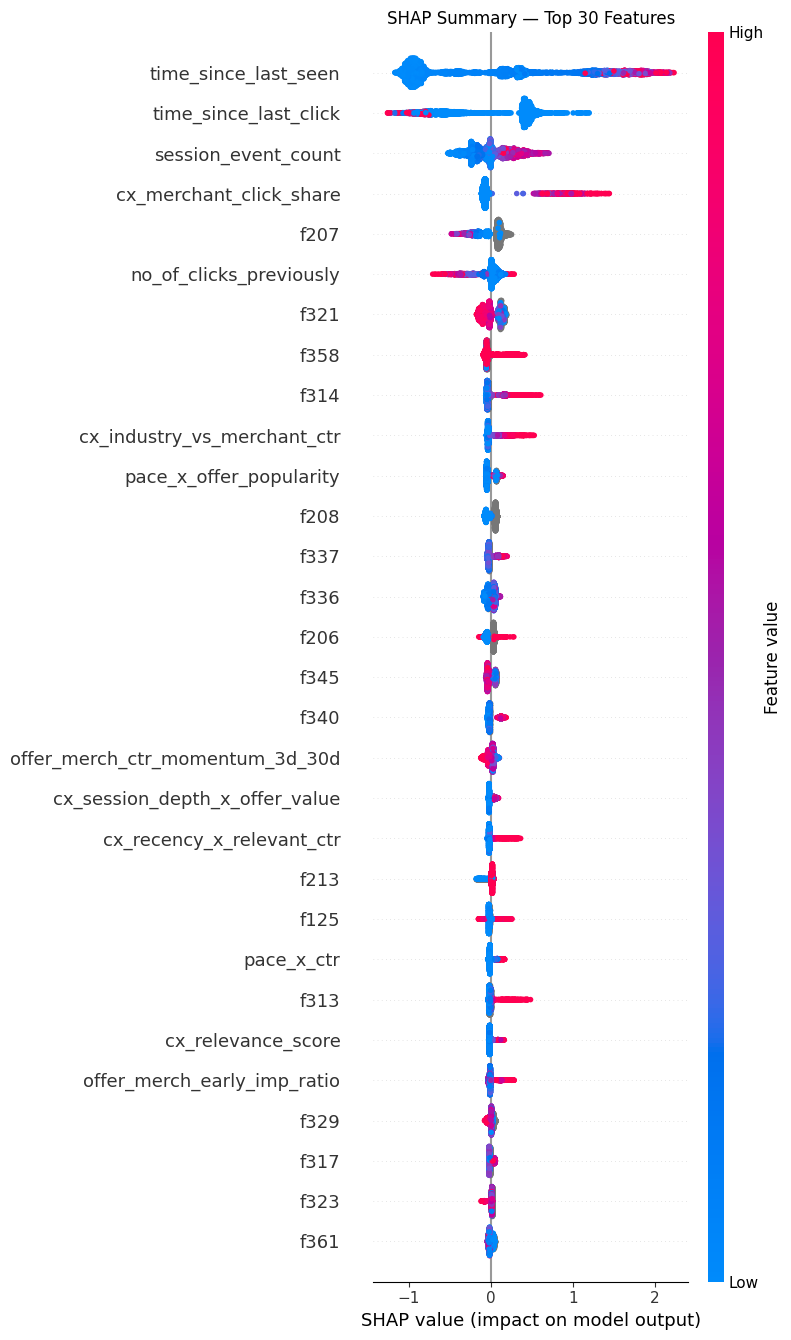

In [37]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, max_display=30, show=False)
plt.title('SHAP Summary — Top 30 Features')
plt.tight_layout()
plt.show()

### 12c. SHAP Bar Plot (Mean |SHAP|)

Horizontal bar chart of mean absolute SHAP value per feature — pure magnitude importance.  
Top 30 features shown.

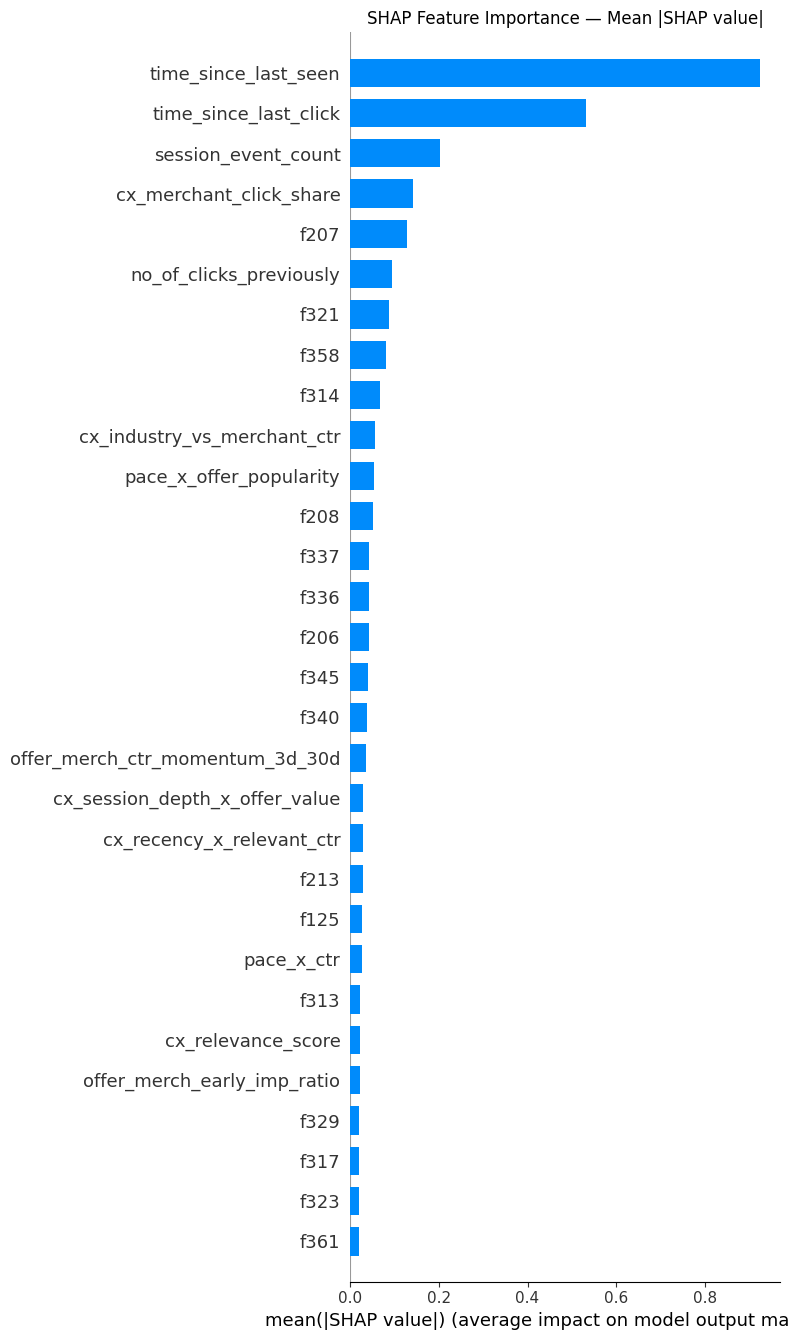

In [38]:
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=30, show=False)
plt.title('SHAP Feature Importance — Mean |SHAP value|')
plt.tight_layout()
plt.show()

### 12d. SHAP Dependence Plots — Top 4 Features

One plot per top-4 feature (ranked by mean |SHAP|).  
X-axis = feature value, Y-axis = SHAP value. Color = auto-selected interaction feature.  
Reveals non-linear relationships and interaction effects.

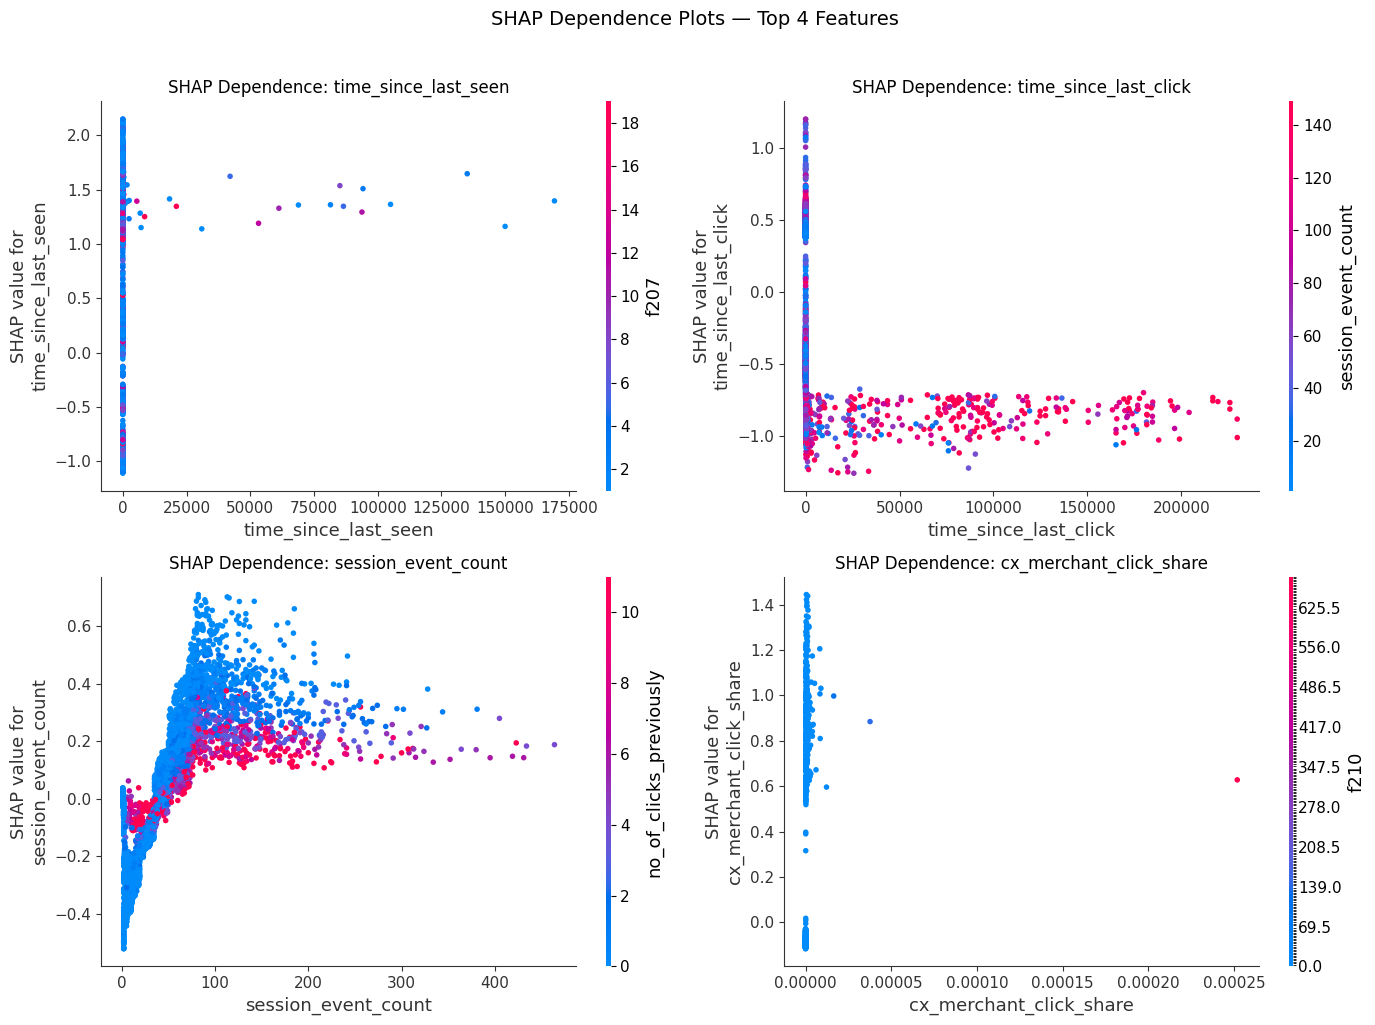

In [39]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_features = np.array(FEATURE_COLS)[np.argsort(mean_abs_shap)[::-1][:4]]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.ravel(), top_features):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')
plt.suptitle('SHAP Dependence Plots — Top 4 Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 12e. SHAP Waterfall — Single Prediction

Waterfall chart for `X_shap.iloc[0]` (first sample in the SHAP subset).  
Shows how each feature pushes the output up or down from `explainer.expected_value`.  
Top 20 contributing features shown.

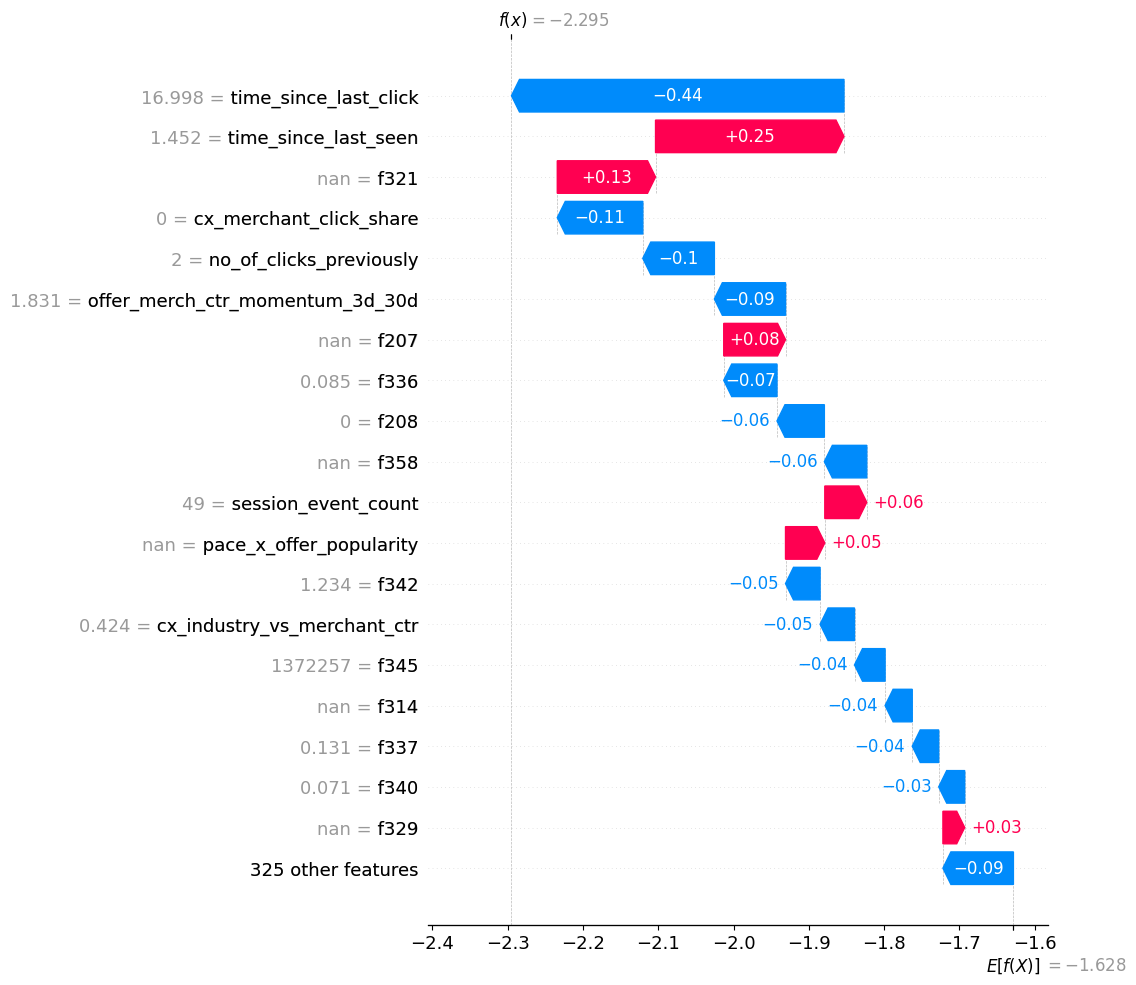

In [40]:
shap.initjs()

sample_idx = 0
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_idx],
    feature_names=FEATURE_COLS
), max_display=20, show=True)

---
## Summary

| Step | Detail |
|---|---|
| Datasets | `featured_full_train.csv` / `featured_full_test.csv` |
| Leaky cols | Dropped at load (`_grp_pct`, `_grp_zscore`, `_is_train`) |
| Sorting | By `id2` (customer) for contiguous LTR groups |
| Categoricals | `CAT_FEATURES = []` — all already int-encoded by `feature_engineering.ipynb` |
| Tuning | Optuna TPE — 20 trials × 3-Fold CV (maximize MAP@7) |
| Loss | `YetiRank` (pairwise LTR), eval metric `MAP:top=7` |
| Hardware | GPU (`task_type='GPU'`, `grow_policy='Depthwise'`) |
| CV | 3-Fold customer-level split on **full train** |
| Metric | MAP@7 — OOF + test; also AUC reported |
| SHAP | TreeExplainer — beeswarm summary, bar, dependence, waterfall |